In [ ]:
## Deep CCA
from cca_zoo.deepmodels import DCCA
from cca_zoo.deepmodels import architectures
dim_cca = 3
encoder_1 = architectures.Encoder(latent_dims=dim_cca, feature_size=20)
encoder_2 = architectures.Encoder(latent_dims=dim_cca, feature_size=10)

ImportError: cannot import name '_BaseCCA' from 'cca_zoo.models._base' (e:\Anaconda\envs\bio\Lib\site-packages\cca_zoo\models\_base.py)

In [1]:
import numpy as np

# Create synthetic data for two views
train_view_1 = np.random.normal(size=(100, 20))
train_view_2 = np.random.normal(size=(100, 10))

# Normalize the data by removing the mean
train_view_1 -= train_view_1.mean(axis=0)
train_view_2 -= train_view_2.mean(axis=0)

from cca_zoo.models import CCA

latent_dimensions = 3
linear_cca = CCA(latent_dims=latent_dimensions)

# Fit the model
# linear_cca.fit((train_view_1, train_view_2))
# view1_cca, view2_cca = linear_cca.fit_transform((train_view_1, train_view_2))

To use iterative methods please install pytorch-lightning from version 2.0.0


In [3]:
from cca_zoo.models import rCCA
from cca_zoo.model_selection import GridSearchCV

# Custom scoring function
def scorer(estimator, X):
    dim_corrs = estimator.score(X)
    return dim_corrs.mean()

# Define grid of potential regularization parameters
c1 = [0.1, 0.3, 0.7, 0.9]
c2 = [0.1, 0.3, 0.7, 0.9]
param_grid = {'c': [c1, c2]}

cv = 5  # Number of folds in cross-validation

# Conduct grid search
ridge = GridSearchCV(rCCA(latent_dims=latent_dimensions), param_grid=param_grid,
                     cv=cv, verbose=True, scoring=scorer).fit((train_view_1, train_view_2)).best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get transformed data (canonical variates)
view1_transformed, view2_transformed = ridge.transform((train_view_1, train_view_2))

# Calculate correlation scores for each dimension
correlations = ridge.score((train_view_1, train_view_2))

print(f"Best regularization parameters: c = {ridge.c}")
print(f"Correlations per dimension: {correlations}")
print(f"Mean correlation: {correlations.mean():.4f}")


Best regularization parameters: c = [0.3, 0.1]
Correlations per dimension: [0.64291985 0.6125483  0.56843658]
Mean correlation: 0.6080


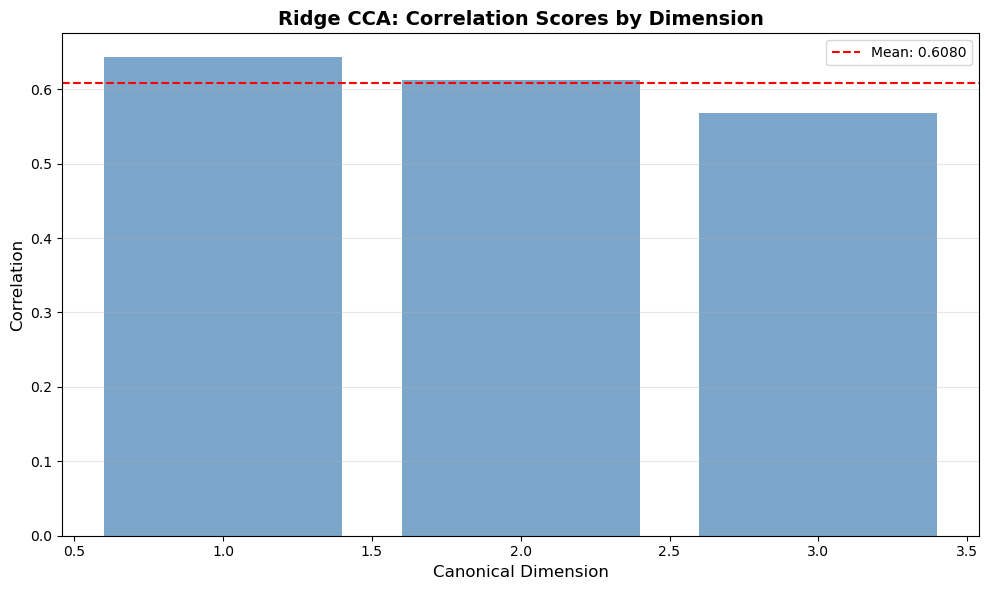

In [6]:
# Visualize correlation scores
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(correlations) + 1), correlations, color='steelblue', alpha=0.7)
plt.axhline(y=correlations.mean(), color='red', linestyle='--', label=f'Mean: {correlations.mean():.4f}')
plt.xlabel('Canonical Dimension', fontsize=12)
plt.ylabel('Correlation', fontsize=12)
plt.title('Ridge CCA: Correlation Scores by Dimension', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


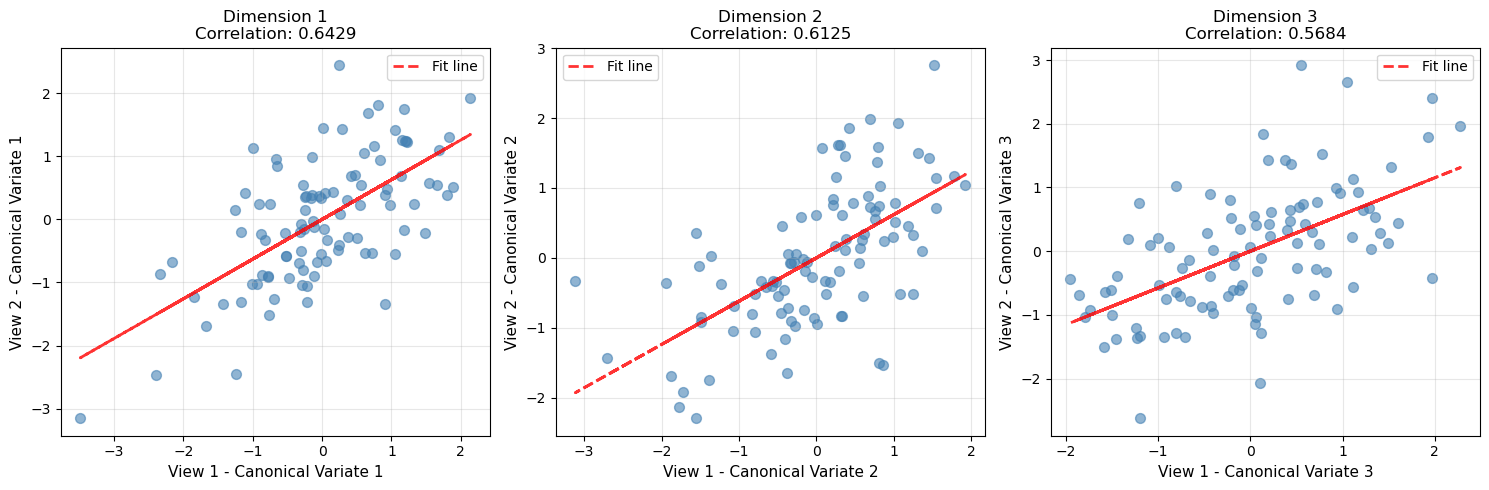

In [7]:
# Scatter plots of canonical variates for first 3 dimensions
fig, axes = plt.subplots(1, min(3, latent_dimensions), figsize=(5*min(3, latent_dimensions), 5))
if latent_dimensions == 1:
    axes = [axes]
    
for dim in range(min(3, latent_dimensions)):
    ax = axes[dim]
    ax.scatter(view1_transformed[:, dim], view2_transformed[:, dim], 
               alpha=0.6, s=50, c='steelblue')
    ax.set_xlabel(f'View 1 - Canonical Variate {dim+1}', fontsize=11)
    ax.set_ylabel(f'View 2 - Canonical Variate {dim+1}', fontsize=11)
    ax.set_title(f'Dimension {dim+1}\nCorrelation: {correlations[dim]:.4f}', fontsize=12)
    ax.grid(alpha=0.3)
    
    # Add correlation line
    z = np.polyfit(view1_transformed[:, dim], view2_transformed[:, dim], 1)
    p = np.poly1d(z)
    ax.plot(view1_transformed[:, dim], p(view1_transformed[:, dim]), 
            "r--", alpha=0.8, linewidth=2, label='Fit line')
    ax.legend()
    
plt.tight_layout()
plt.show()


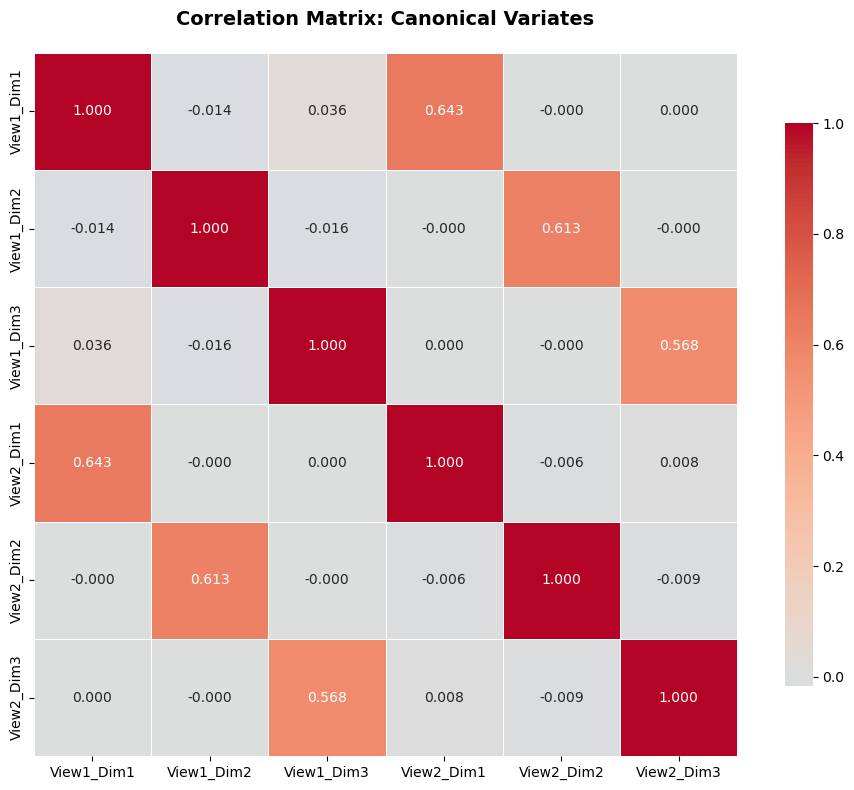

In [8]:
# Correlation matrix heatmap
corr_matrix = np.corrcoef(view1_transformed.T, view2_transformed.T)
n_dims = latent_dimensions

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            xticklabels=[f'View1_Dim{i+1}' for i in range(n_dims)] + 
                       [f'View2_Dim{i+1}' for i in range(n_dims)],
            yticklabels=[f'View1_Dim{i+1}' for i in range(n_dims)] + 
                       [f'View2_Dim{i+1}' for i in range(n_dims)],
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Canonical Variates', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


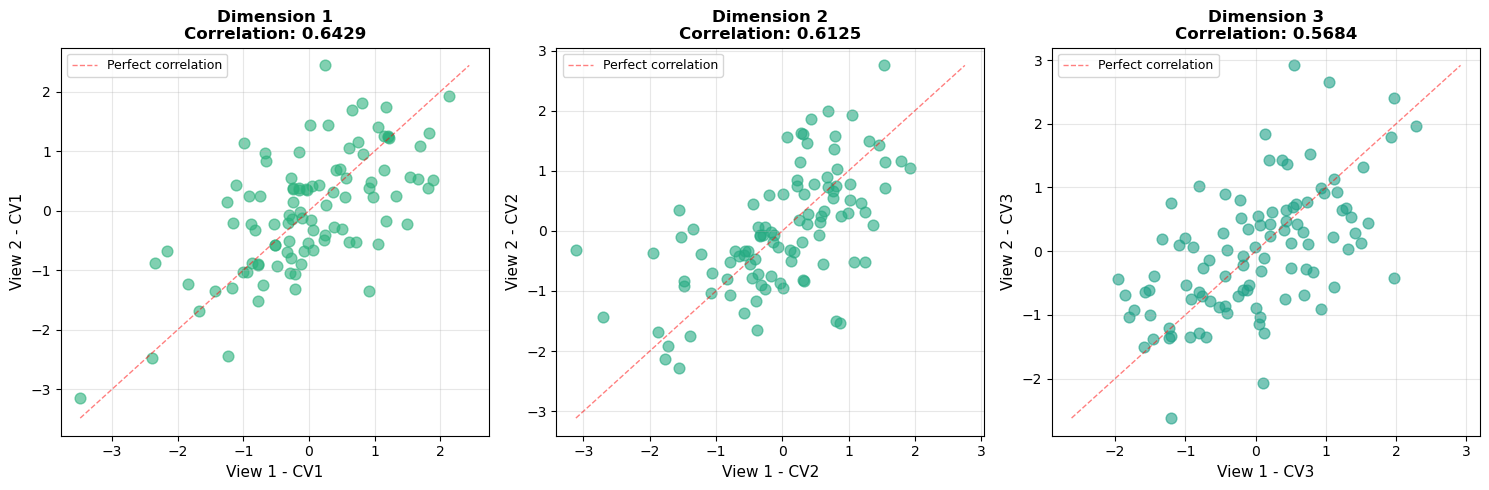

In [9]:
# Pairwise correlation plot for all dimensions
fig, axes = plt.subplots(1, latent_dimensions, figsize=(5*latent_dimensions, 5))
if latent_dimensions == 1:
    axes = [axes]

for dim in range(latent_dimensions):
    ax = axes[dim]
    # Calculate actual correlation
    actual_corr = np.corrcoef(view1_transformed[:, dim], view2_transformed[:, dim])[0, 1]
    
    # Use color based on correlation value
    color = plt.cm.viridis(correlations[dim])
    ax.scatter(view1_transformed[:, dim], view2_transformed[:, dim], 
               alpha=0.6, s=60, c=[color])
    ax.set_xlabel(f'View 1 - CV{dim+1}', fontsize=11)
    ax.set_ylabel(f'View 2 - CV{dim+1}', fontsize=11)
    ax.set_title(f'Dimension {dim+1}\nCorrelation: {correlations[dim]:.4f}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    
    # Add diagonal line for perfect correlation reference
    min_val = min(view1_transformed[:, dim].min(), view2_transformed[:, dim].min())
    max_val = max(view1_transformed[:, dim].max(), view2_transformed[:, dim].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, linewidth=1, label='Perfect correlation')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
